<a href="https://colab.research.google.com/github/inoorulameen2005-crypto/Data-Analytics-using-python-project/blob/main/final%20project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**E-COMMERCE SALES AND PERFORMANCE**

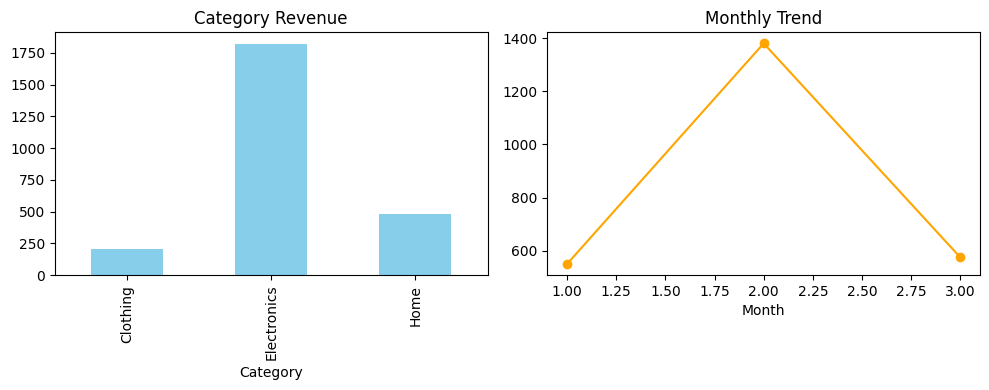

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Create dataset
data = {
    'OrderID': [101, 102, 103, 104, 105, 106, 107, 108],
    'Date': ['2026-01-15', '2026-01-16', '2026-02-10', '2026-02-12',
             '2026-03-05', '2026-03-06', '2026-03-15', '2026-03-20'],
    'Category': ['Electronics', 'Clothing', 'Electronics', 'Home',
                 'Clothing', 'Home', 'Electronics', 'Clothing'],
    'Quantity': [1, 2, 1, 4, 1, 2, 3, 5],
    'UnitPrice': [500, 25, 1200, 45, 80, 150, 40, 15],
    'CustomerID': ['C1', 'C2', 'C1', 'C3', 'C4', 'C2', 'C5', 'C3']
}
df = pd.DataFrame(data)

# 2. Data Cleaning
df.drop_duplicates(inplace=True)
df['Quantity'] = df['Quantity'].fillna(1)
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Extract month from Date
df['Month'] = pd.to_datetime(df['Date']).dt.month

# 3. Quick Analysis
prod_sales = df.groupby('Category')['Revenue'].sum()
monthly_sales = df.groupby('Month')['Revenue'].sum()

# 4. Visualization
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

prod_sales.plot(kind='bar', ax=axes[0], color='skyblue', title='Category Revenue')
monthly_sales.plot(kind='line', ax=axes[1], color='orange', marker='o', title='Monthly Trend')

plt.tight_layout()
plt.show()

**E-COMMERCE DATASET**

In [29]:
# Dummy dataset simulating e-commerce orders
data = {
    'OrderID': [101, 102, 103, 104, 105, 106, 107, 108],
    'Date': ['2026-01-15', '2026-01-16', '2026-02-10', '2026-02-12', '2026-03-05', '2026-03-06', '2026-03-15', '2026-03-20'],
    'Category': ['Electronics', 'Clothing', 'Electronics', 'Home', 'Clothing', 'Home', 'Electronics', 'Clothing'],
    'Quantity': [1, 2, 1, 4, 1, 2, 3, 5],
    'UnitPrice': [500, 25, 1200, 45, 80, 150, 40, 15],
    'CustomerID': ['C1', 'C2', 'C1', 'C3', 'C4', 'C2', 'C5', 'C3']
}

df = pd.DataFrame(data)

# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'])
df.head()

,OrderID,Date,Category,Quantity,UnitPrice,CustomerID
0,101,2026-01-15,Electronics,1,500,C1
1,102,2026-01-16,Clothing,2,25,C2
2,103,2026-02-10,Electronics,1,1200,C1
3,104,2026-02-12,Home,4,45,C3
4,105,2026-03-05,Clothing,1,80,C4


**DATA CLEANING**

In [30]:
# Check for missing values
print("Missing values:\n", df.isnull().sum())

# Calculate Total Sales (Revenue) for each transaction
df['Total_Sales'] = df['Quantity'] * df['UnitPrice']

# Extract Month for seasonal trend tracking
df['Month'] = df['Date'].dt.to_period('M')
df.head()

Missing values:
 OrderID       0
Date          0
Category      0
Quantity      0
UnitPrice     0
CustomerID    0
dtype: int64


,OrderID,Date,Category,Quantity,UnitPrice,CustomerID,Total_Sales,Month
0,101,2026-01-15,Electronics,1,500,C1,500,2026-01
1,102,2026-01-16,Clothing,2,25,C2,50,2026-01
2,103,2026-02-10,Electronics,1,1200,C1,1200,2026-02
3,104,2026-02-12,Home,4,45,C3,180,2026-02
4,105,2026-03-05,Clothing,1,80,C4,80,2026-03


**SALES PERFORMANCE ANALYSIS**

  **OVERALL PERFORMANCE**

In [31]:
total_revenue = df['Total_Sales'].sum()
total_orders = df['OrderID'].nunique()
average_order_value = total_revenue / total_orders

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Orders: {total_orders}")
print(f"Average Order Value (AOV): ${average_order_value:,.2f}")

Total Revenue: $2,505.00
Total Orders: 8
Average Order Value (AOV): $313.12


**BEST SELLING CATEGORY**

In [32]:
category_perf = df.groupby('Category').agg({'Quantity': 'sum', 'Total_Sales': 'sum'}).reset_index()
category_perf = category_perf.sort_values(by='Total_Sales', ascending=False)
print("\nCategory Performance:\n", category_perf)


Category Performance:
       Category  Quantity  Total_Sales
1  Electronics         5         1820
2         Home         6          480
0     Clothing         8          205


**TOTAL SALEES **

/tmp/ipykernel_812/2090393654.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Total_Sales', data=category_perf, palette='Blues_r')


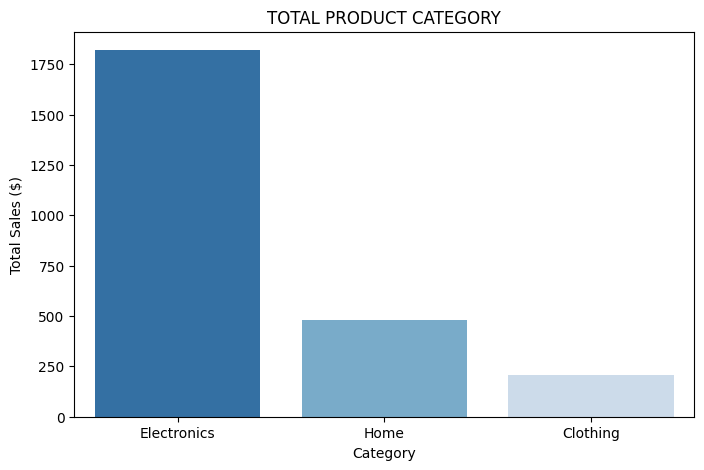

In [33]:
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.barplot(x='Category', y='Total_Sales', data=category_perf, palette='Blues_r')
plt.title('TOTAL PRODUCT CATEGORY')
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.show()

**MONTHLY SALES PRODUCT**

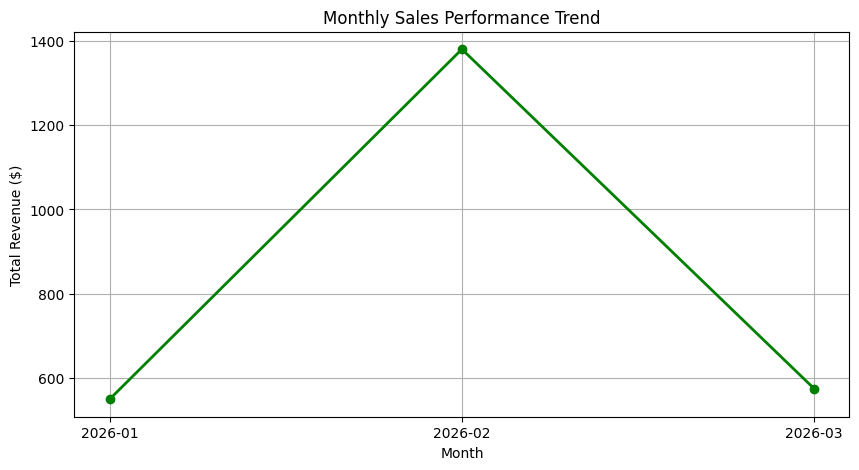

In [34]:
monthly_sales = df.groupby('Month')['Total_Sales'].sum().reset_index()
monthly_sales['Month'] = monthly_sales['Month'].astype(str) # Convert period to string for plotting

plt.figure(figsize=(10, 5))
plt.plot(monthly_sales['Month'], monthly_sales['Total_Sales'], marker='o', color='green', linewidth=2)
plt.title('Monthly Sales Performance Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue ($)')
plt.grid(True)
plt.show()